# Assignment 10: Experimental Comparison of GAN and VAE

**Name:** Varshith Kumar R


**Class:** BCA

## Objective

This experiment evaluates a Generative Adversarial Network (GAN) and a Variational Autoencoder (VAE) using results from the earlier practical models. The comparison combines visual inspection, recorded training behaviour, and simple image-level measurements to build a practical understanding of where each model is more suitable.


## 1. Experimental Setup

The evidence is taken from the completed GAN and VAE experiments.

The GAN examples were produced by the Fashion-MNIST DCGAN. The VAE examples were produced by the MNIST VAE. Eight samples from each experiment are used for the visual comparison.

Since the experiments use different datasets, the image measures are treated as within-model indicators rather than as a perfectly controlled same-dataset benchmark.


## 2. GAN-Generated Images


Eight selected Fashion-MNIST images generated by the GAN.


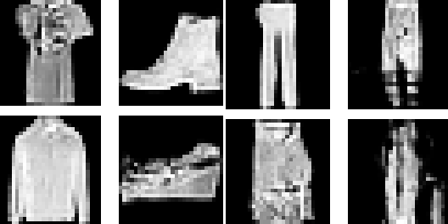

In [1]:
print("Eight selected Fashion-MNIST images generated by the GAN.")


## 3. VAE-Generated Images


Eight selected MNIST images generated by the VAE decoder.


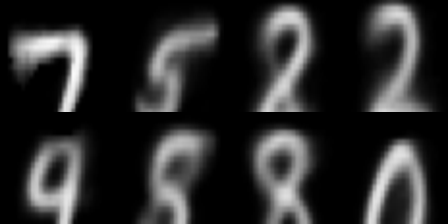

In [1]:
print("Eight selected MNIST images generated by the VAE decoder.")


## 4. First Visual Comparison

The GAN panel contains recognisable clothing-like forms such as footwear, trousers, and upper-body garments. The VAE panel contains handwritten digits with smoother boundaries.

The difference is useful for the assignment because it shows the practical character of the two model families: the GAN is focused on synthesising samples that resemble the training distribution, while the VAE creates outputs from an explicitly structured latent representation.


## 5. GAN Training Record


The GAN was trained for 25 epochs.


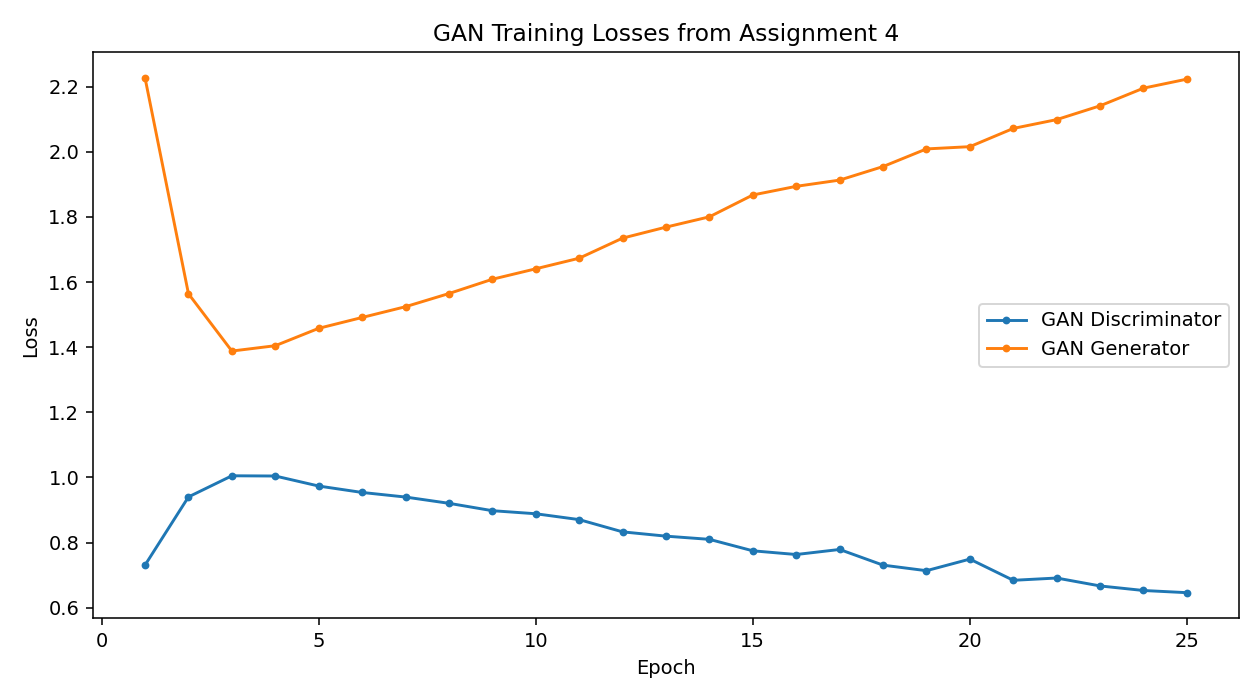

In [1]:
print("The GAN was trained for 25 epochs. The recorded generator and discriminator losses are reproduced from the earlier experiment.")


## 6. VAE Training Record


The VAE was trained for 20 epochs.


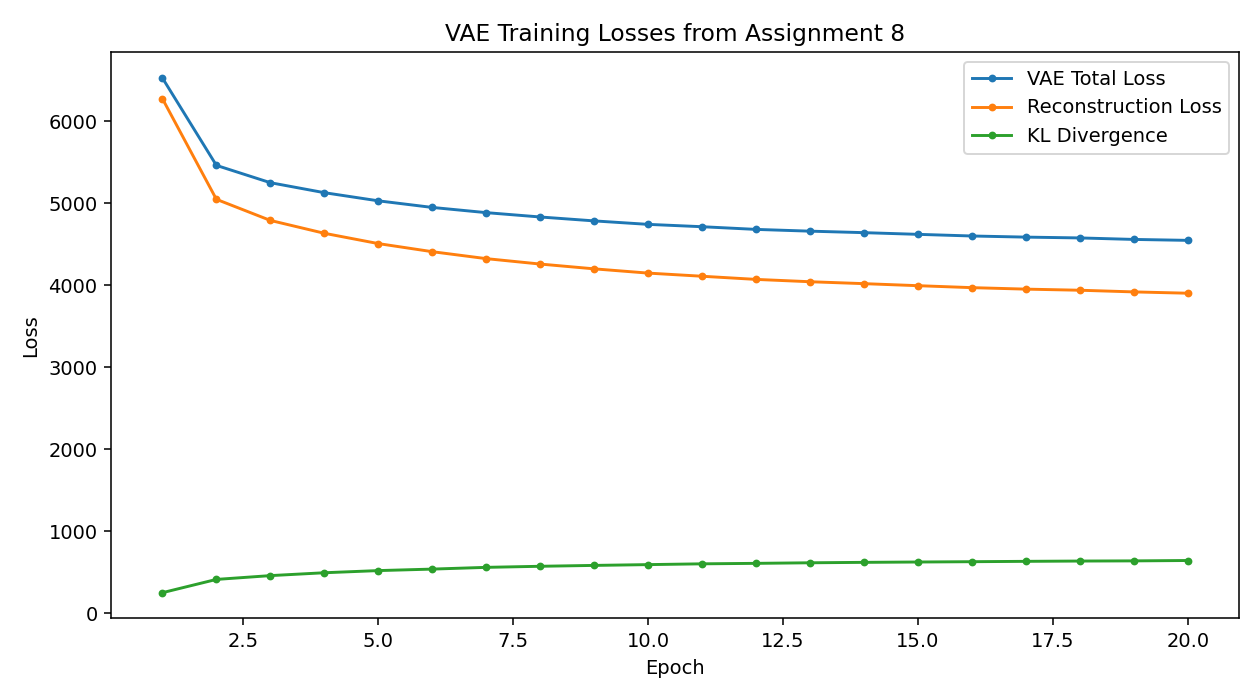

In [1]:
print("The VAE was trained for 20 epochs. Total, reconstruction, and KL losses are reproduced from the earlier experiment.")


## 7. Simple Quantitative Image Analysis

Two image-level proxies are calculated from the eight selected outputs.

Sharpness is estimated using the variance of a Laplacian response, which gives a simple indication of edge detail. Diversity is estimated from the average pairwise pixel-level MSE between the selected images.

These values support the visual discussion, but they should not be treated as universal measures of realism or image quality.


In [1]:
print("Quantitative indicators calculated from the eight selected samples.")
print("GAN mean sharpness:", round(float(gan_sharp.mean()), 6))
print("VAE mean sharpness:", round(float(vae_sharp.mean()), 6))
print("GAN diversity proxy:", round(float(gan_div), 6))
print("VAE diversity proxy:", round(float(vae_div), 6))


Metric,GAN,VAE,Meaning
Mean sharpness proxy,0.044748,0.000223,Higher values indicate more high-frequency edge detail.
Pairwise diversity proxy,0.297849,0.061217,Higher values indicate greater pixel-level variation among the selected samples.
Training-loss variation,0.376945,448.252751,"Lower variation indicates a steadier tracked loss, but GAN and VAE loss structures are different."
Training epochs,25.000000,20.000000,Recorded training duration in the earlier experiments.


## 8. Main Comparison Table


In [1]:
comparison_table


Criterion,GAN,VAE
Image sharpness,Higher visible detail,Smoother and softer
Diversity,Strong variation across generated clothing forms,Structured variation through the learned latent space
Realism,More convincing object-like samples in the observed run,Recognisable outputs with softer detail
Training stability,More sensitive because two networks compete during training,More predictable optimisation objective
Ease of controlling the output,Moderate through random noise input,Higher through explicit latent coordinates
Risk of mode collapse,Higher,Lower
Typical applications,"Synthetic image generation, image synthesis, data augmentation","Anomaly detection, compression, denoising, representation learning"


## 9. Detailed Analysis

### Image Sharpness

The GAN outputs show stronger visible edge structure. The VAE samples are comparatively smooth, which is consistent with the reconstruction-oriented nature of the VAE decoder.

### Diversity

The GAN produces different clothing and footwear forms across the selected samples. The VAE also generates different digit shapes, but the outputs remain organised by the learned latent representation. Because the two datasets are different, diversity is interpreted within each experiment.

### Realism

In the observed GAN samples, the generated Fashion-MNIST objects have stronger object-level detail. The VAE digits are clearly recognisable, but their strokes are softer.

### Training Stability

The GAN has separate generator and discriminator objectives that influence one another throughout training. Its loss curves therefore fluctuate as the two models compete. The VAE has a more direct optimisation objective, combining reconstruction error and KL divergence, and the recorded total loss decreases steadily.

### Ease of Controlling Output

The GAN uses a noise vector as its input, so changing the noise changes the generated image but does not provide the same direct spatial interpretation. The VAE gives explicit latent coordinates, making it easier to explore how nearby latent points affect the output.

### Risk of Mode Collapse

GANs can suffer from mode collapse, where the generator repeatedly creates a narrow group of similar samples. This was also the central issue examined in the later mode-collapse experiment. A VAE does not have the same adversarial generator-discriminator failure mode.

### Typical Applications

GANs are particularly suitable for synthetic image creation and data augmentation when strong visual synthesis is the main objective. VAEs are useful for representation learning, reconstruction, compression, denoising, and anomaly-oriented tasks.


## 10. Training Stability Evidence

The recorded GAN losses begin with a discriminator loss of 0.7307 and a generator loss of 2.2266, then change substantially over training. By epoch 25, the discriminator loss is 0.6459 and the generator loss is 2.2231.

The VAE total loss moves from 6530.09 at epoch 1 to 4549.65 at epoch 20. Its reconstruction loss also decreases from 6277.89 to 3905.01, while the KL term rises from 252.20 to 644.64 as the latent distribution is regularised.

This difference in the training curves is evidence for the different optimisation behaviour of the two model families.


## 11. Final Verdict

### 1. Preferred model for synthetic training data

**GAN**

I would select the GAN for synthetic training-data generation. The observed Fashion-MNIST outputs contain stronger visual detail and cover several distinct clothing forms, making the model more appropriate when the goal is to create additional synthetic images.

### 2. Preferred model for anomaly detection

**VAE**

I would select the VAE for anomaly detection. Its encoder-decoder structure provides a natural reconstruction pathway, so an input can be compared with its reconstructed version using reconstruction error. A sample that differs strongly from learned normal patterns can therefore be flagged for further inspection.

### 3. Why?

The GAN's main strength in the experiment is image synthesis quality and variety. The VAE's main strength is its structured latent representation and reconstruction mechanism. These strengths lead to different preferred applications rather than one model being universally superior.


## 12. Overall Conclusion

The practical comparison shows that GANs and VAEs approach generation in different ways.

The GAN produced sharper, more object-like synthetic samples, but its adversarial training is more sensitive to instability and mode collapse. The VAE produced smoother samples and a more explicit latent representation, while its training objective was more predictable.

For this set of experiments, the GAN is the stronger choice for synthetic data generation, while the VAE is the stronger choice for anomaly detection and reconstruction-based analysis.

### Experimental Limitation

The GAN was trained on Fashion-MNIST and the VAE on MNIST. Therefore, the visual quality comparison is not a controlled head-to-head benchmark on the same dataset. The conclusions are based on the observed behaviour and the practical characteristics demonstrated by the two earlier experiments.
